In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [21]:
import xarray as xr
import pandas as pd
import numpy as np

from glob import glob
from stericheight.data_handler import *
from stericheight.steric_height import *
from functions import Functions
from composite import Composite

fns = Functions()

In [3]:
files=glob('../data/sip/*.asci')

In [4]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [5]:
# check lats and lons are always the same
first=True
for f in files:
    data = pd.read_csv(f,sep='\\s+',names=['lon','lat','ice'])
    lats = data['lat']
    lons = data['lon']
    if not first:
        if (sum(lats-lastlat) > 0) or (sum(lons-lastlon) >0):
            print(f)
            break
    lastlat = lats
    lastlon = lons
    first=False



In [6]:
times=[]
alldata=[]#np.array([len(lats),len(files)])
for n,f in enumerate(files):
    filedate=str.split(f,'/')[3].split('.')[0]
    yyyy=filedate[0:4]
    mm=filedate[4:6]
    times.append(pd.Timestamp(int(yyyy),int(mm),1))

    data = pd.read_csv(f,sep='\\s+',names=['lon','lat','ice'])
    # data['ice'].to_xarray().assign_coords({'time':pd.Timestamp(int(yyyy),int(mm),1)})
    alldata.append(data['ice'].to_list())    



In [7]:
sip=xr.DataArray(data=alldata,coords={'time':times,'index':np.arange(len(data))})
sip_ds=xr.Dataset(data_vars={'sip':sip,'lat':xr.DataArray(data=lats,coords={'index':sip.index}),'lon':xr.DataArray(data=lons,coords={'index':sip.index})})

In [8]:
sip = sip.assign_coords({'lat':sip_ds.lat,'lon':sip_ds.lon})

In [9]:
elevation = elevation_.sel(latitude = slice(sip.lat.min(), sip.lat.max()), longitude = slice(sip.lon.min(),sip.lon.max()))

In [10]:
sip['elevation']=elevation.interp(latitude=sip.lat,longitude=sip.lon)

In [11]:
sip['month'] = sip.time.dt.month

In [12]:
m3to6 = sip.where((sip.month >= 3) & (sip.month <=6) ,drop=True)
m7to10 = sip.where((sip.month >= 7) & (sip.month <=10) ,drop=True)

In [13]:
m3to6.max()

<xarray.DataArray ()> Size: 8B
array(4.277428)

In [14]:

extent=[139,150,-68,-65]
elev2 = fns.crop_to_extent(elevation,extent)

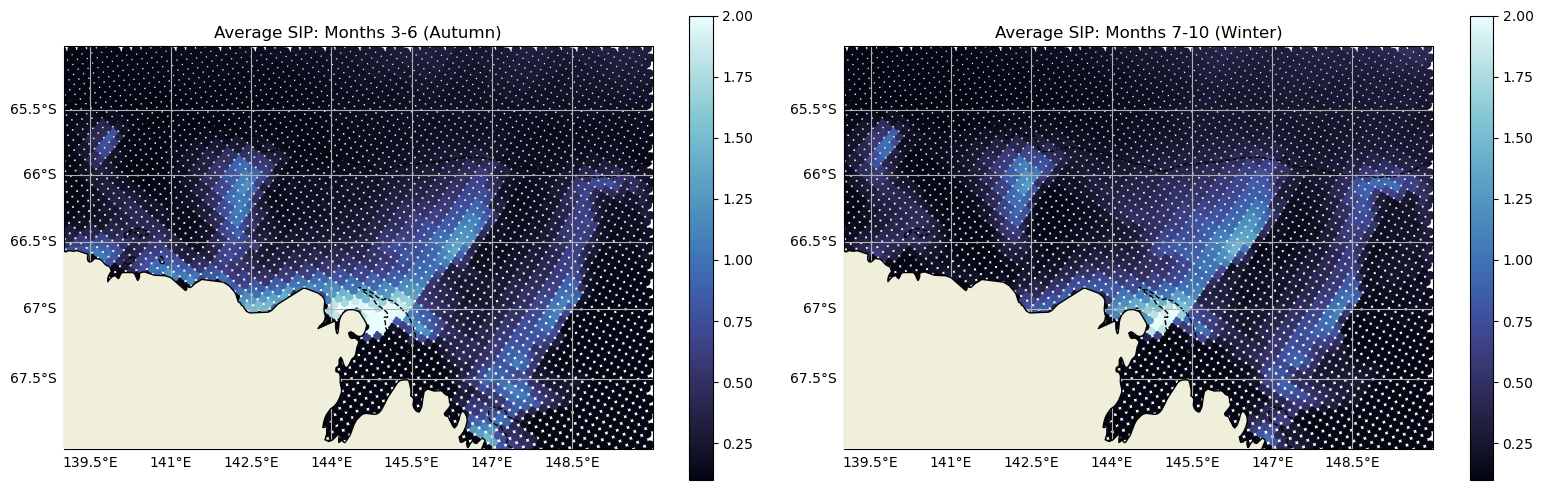

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND

m3 = m3to6.mean('time')
m7 = m7to10.mean('time')


fig, ax = plt.subplots(1,2,figsize=(16,5),subplot_kw={'projection':ccrs.Mercator()})

def plot(ax,t,title,vmin=0.1,vmax=2,cmap=cmocean.cm.ice):
    #t = t.where(~(t < 0.0000001))
    im=ax.scatter(t.lon, t.lat, c=t, s=28, transform=ccrs.PlateCarree(),cmap=cmap, vmin=vmin, vmax=vmax)#, alpha=0.9)
    elev2.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')
    ax.set_title(title)
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k',zorder=3)
    gl = ax.gridlines(draw_labels=True)
    fig.colorbar(im,ax=ax)

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

plot(ax[0],m3,'Average SIP: Months 3-6 (Autumn)')
plot(ax[1],m7,'Average SIP: Months 7-10 (Winter)')
plt.tight_layout()


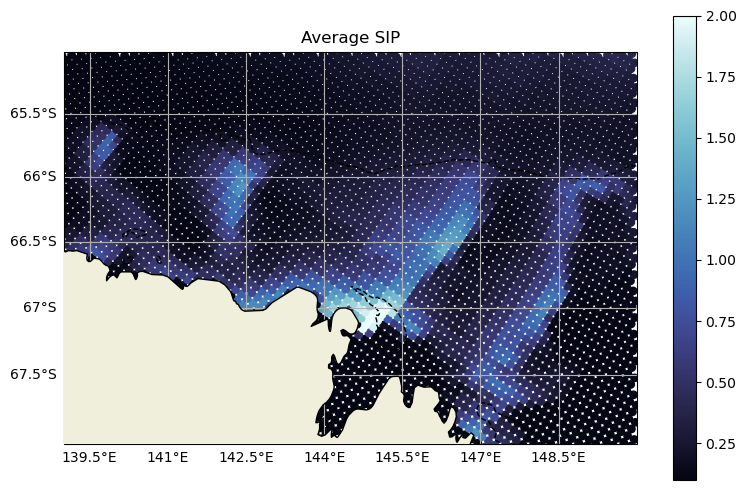

In [16]:

fig, ax = plt.subplots(1,1,figsize=(8,5),subplot_kw={'projection':ccrs.Mercator()})


plot(ax,sip.mean('time'),'Average SIP')
plt.tight_layout()

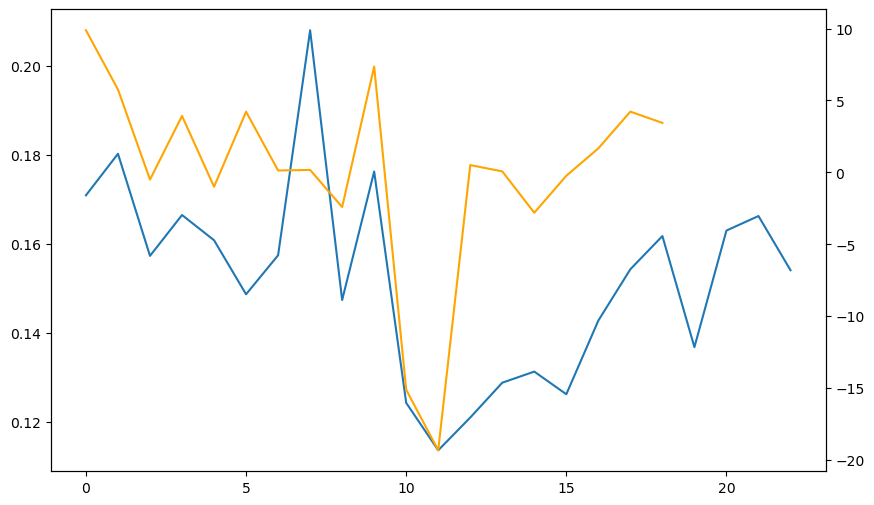

In [18]:
fig,ax = plt.subplots(1,1,figsize=(10,6))
gi = xr.open_dataarray('gyre_index.nc')
ax.plot(sip.mean('index').groupby('time.year').mean())
ax.twinx().plot(gi.groupby('time.year').mean(),c='orange')

In [19]:
sip.to_netcdf('sip.nc')

In [40]:
gii = gi.interp({'time':sip.time})
cmp = Composite(gii.rolling({'time':12},center=True).mean(),'Gyre Index',frac=0.2)

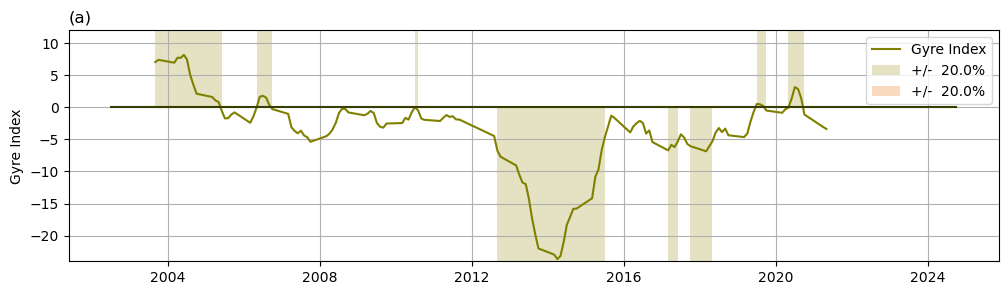

In [41]:
fig,ax = plt.subplots(1,1,figsize=(12,3))
cmp.composite_timeseries(ax,ylim=[-24,12])


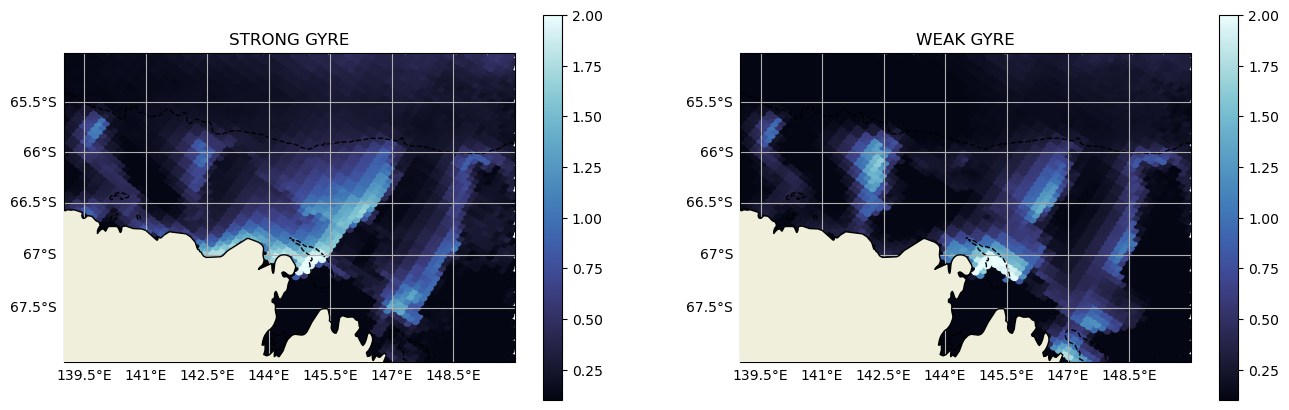

In [42]:
# extract data where positive and negative
sip_pos = sip.where(cmp.idx_positive_with_lag,drop=True).mean('time')
sip_neg = sip.where(cmp.idx_negative_with_lag,drop=True).mean('time')

fig,axs = plt.subplots(1,2,figsize=(16,5),subplot_kw={'projection':ccrs.Mercator()})

# plot pos and neg maps
im1=plot(axs[0],sip_pos,'STRONG GYRE')
im2=plot(axs[1],sip_neg,'WEAK GYRE')


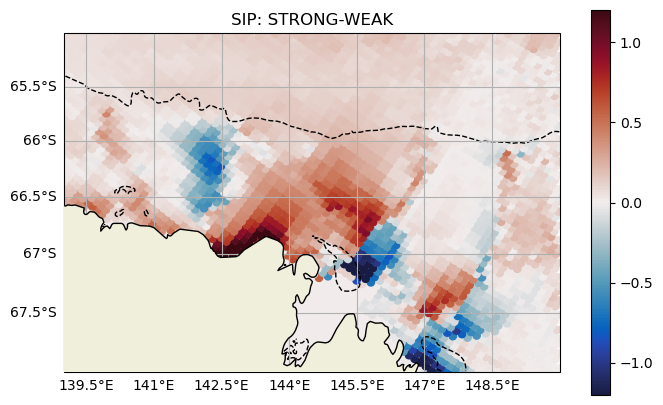

In [43]:
fig,axs = plt.subplots(1,1,figsize=(8,5),subplot_kw={'projection':ccrs.Mercator()})

plot(axs,sip_pos-sip_neg,'SIP: STRONG-WEAK',vmax=1.2,vmin=-1.2,cmap=cmocean.cm.balance)

In [44]:
sic = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__

In [48]:
sic['month'] = sic.time.dt.month
sic_filtered = sic.interp({'time':sip.time})#where((sic.month >=3) & (sic.month <=10),drop=True)
sic_filtered = fns.crop_to_extent(sic,extent)

sic_pos = sic_filtered.where(cmp.idx_positive_with_lag,drop=True).mean('time')
sic_neg = sic_filtered.where(cmp.idx_negative_with_lag,drop=True).mean('time')


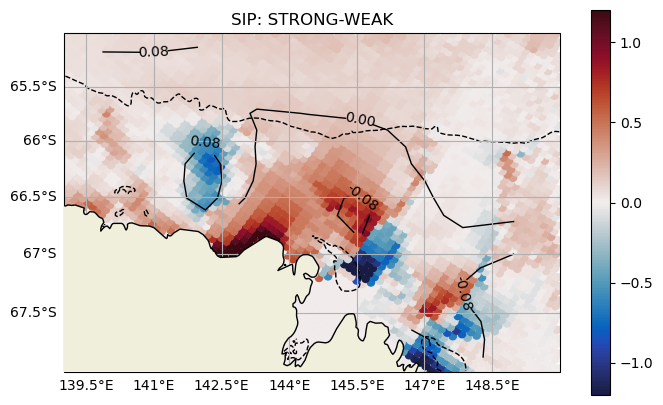

In [49]:
fig,axs = plt.subplots(1,1,figsize=(8,5),subplot_kw={'projection':ccrs.Mercator()})

im=(sic_pos-sic_neg).plot.contour(x='longitude',y='latitude',ax=axs,transform=ccrs.PlateCarree(),levels=[-0.08,0,0.08],colors='k',vmin=-0.15,vmax=0.15,linewidths=1,linestyles='-')
im=axs.clabel(im, inline=True, fontsize=10, fmt='%1.2f')
plot(axs,sip_pos-sip_neg,'SIP: STRONG-WEAK',vmax=1.2,vmin=-1.2,cmap=cmocean.cm.balance)


In [47]:
dot_ds = DOT(ver='egm').ds
lwe_ds = GRACE().ds
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,#sla_,#SLA(deg=1).da,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


In [51]:
sha = sha_ds_sla.sha.interp({'time':sip.time})
sha = fns.crop_to_extent(sha,extent)

In [52]:
sha_pos = sha.where(cmp.idx_positive_with_lag,drop=True).mean('time')
sha_neg = sha.where(cmp.idx_negative_with_lag,drop=True).mean('time')

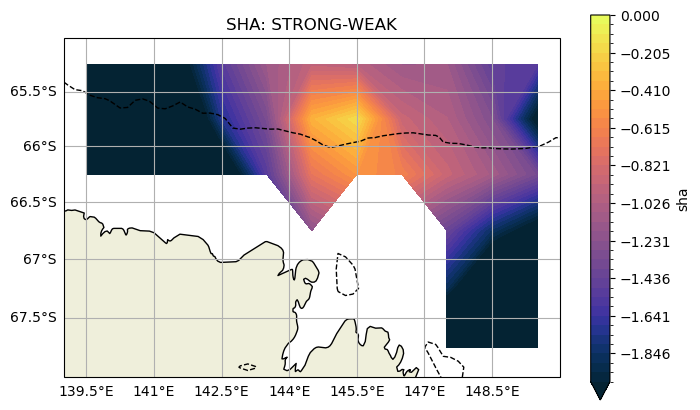

In [ ]:
fig,axs = plt.subplots(1,1,figsize=(8,5),subplot_kw={'projection':ccrs.Mercator()})

fns.plotc(axs,sha_pos-sha_neg,'SHA: STRONG-WEAK',extent,vmin=-2,vmax=0,cmap=cmocean.cm.thermal_r)